<a href="https://colab.research.google.com/github/DeeptiYadav10648/ML_classwork/blob/main/Glass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ensemble
#parameter tuning
#feature


In [ ]:
#load the data
import pandas as pd
import numpy as np

In [ ]:
col = ["id","RI","Na","Mg","Al","Si","K","Ca","Ba","Fe","Type"]

In [ ]:
df = pd.read_csv("glass.data", names=col)
df

,id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
209,210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,213,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      214 non-null    int64  
 1   RI      214 non-null    float64
 2   Na      214 non-null    float64
 3   Mg      214 non-null    float64
 4   Al      214 non-null    float64
 5   Si      214 non-null    float64
 6   K       214 non-null    float64
 7   Ca      214 non-null    float64
 8   Ba      214 non-null    float64
 9   Fe      214 non-null    float64
 10  Type    214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB


In [ ]:
df.describe()

,id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,61.920648,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,54.250000,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,107.500000,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,160.750000,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
df.size

2354

In [ ]:
df.shape

(214, 11)

In [ ]:
df.head()

,id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
# what are the correlation of types

In [ ]:
#correlation
df.corr()

,id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
id,1.000000,-0.072209,0.375722,-0.650328,0.490113,0.061232,0.003149,0.090800,0.451001,-0.072794,0.877357
RI,-0.072209,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,0.375722,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.650328,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,0.490113,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,0.061232,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,0.003149,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.090800,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,0.451001,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,-0.072794,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278


In [ ]:
#feature scaling
import seaborn as sns

<Axes: xlabel='RI', ylabel='Density'>

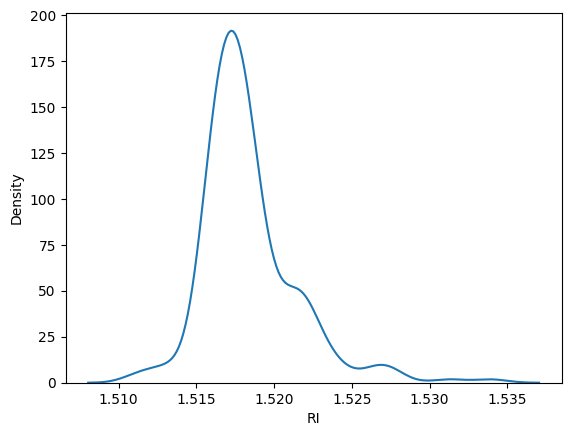

In [ ]:
#kde of all features
sns.kdeplot(df['RI'])

<Axes: xlabel='Na', ylabel='Density'>

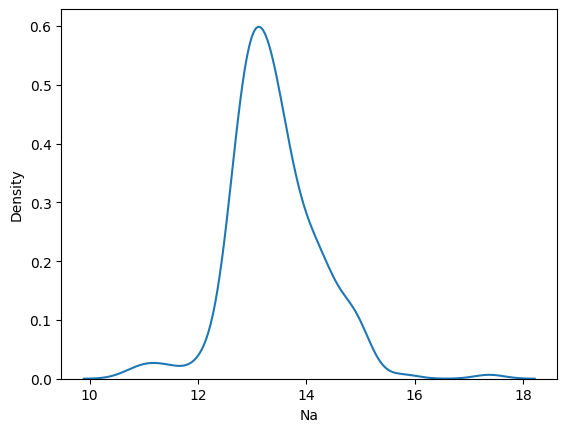

In [ ]:
sns.kdeplot(df['Na'])

<Axes: xlabel='Mg', ylabel='Density'>

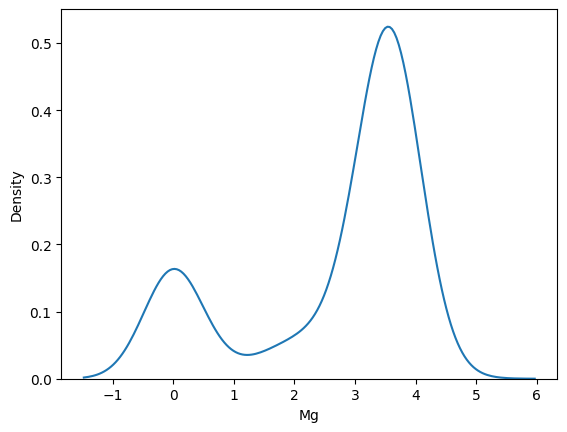

In [ ]:
sns.kdeplot(df['Mg'])

<Axes: xlabel='Al', ylabel='Density'>

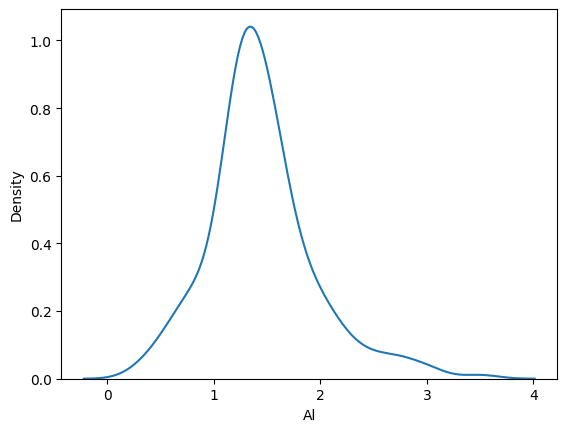

In [ ]:
sns.kdeplot(df['Al'])

<Axes: xlabel='Si', ylabel='Density'>

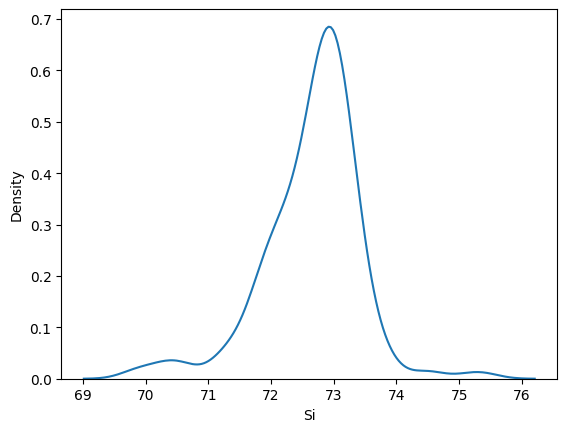

In [ ]:
sns.kdeplot(df['Si'])

<Axes: xlabel='K', ylabel='Density'>

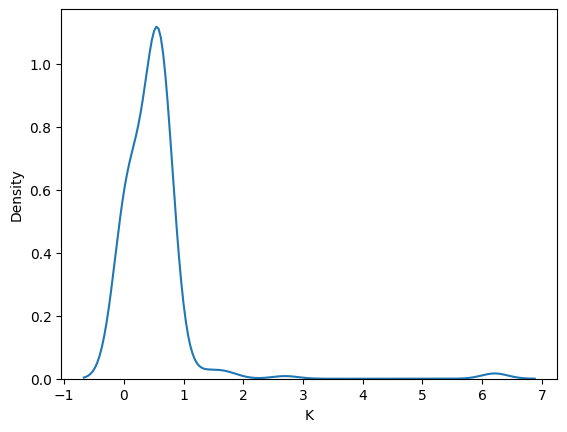

In [ ]:
sns.kdeplot(df['K'])

<Axes: xlabel='Ca', ylabel='Density'>

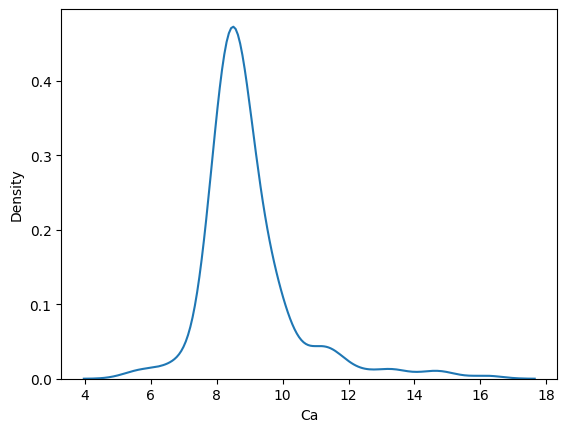

In [ ]:
sns.kdeplot(df['Ca'])

<Axes: xlabel='Ba', ylabel='Density'>

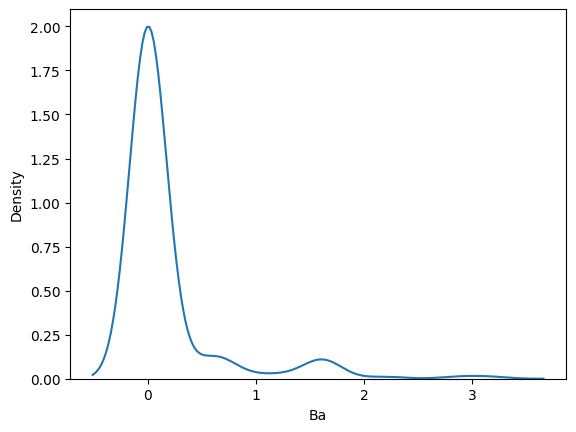

In [ ]:
sns.kdeplot(df['Ba'])

<Axes: xlabel='Fe', ylabel='Density'>

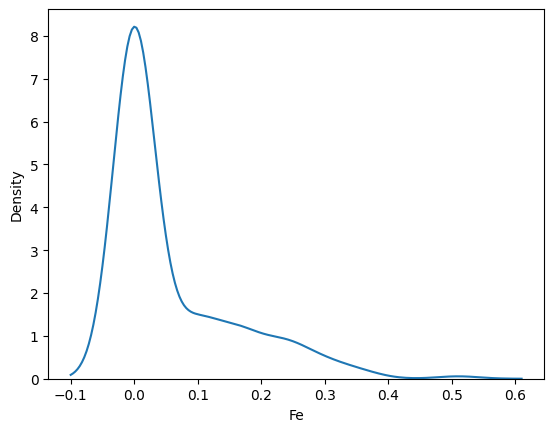

In [ ]:
sns.kdeplot(df['Fe'])

<Axes: ylabel='RI'>

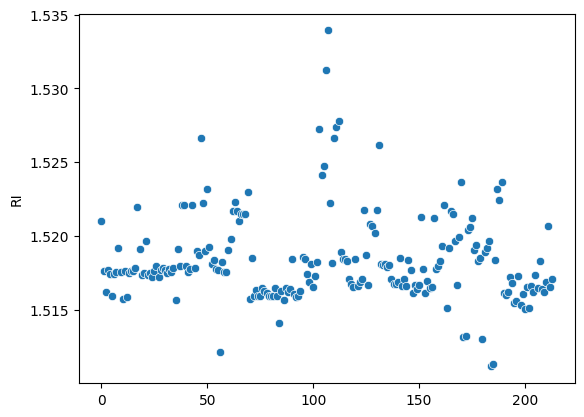

In [ ]:
#scatter plot
sns.scatterplot(df['RI'])

<Axes: ylabel='Na'>

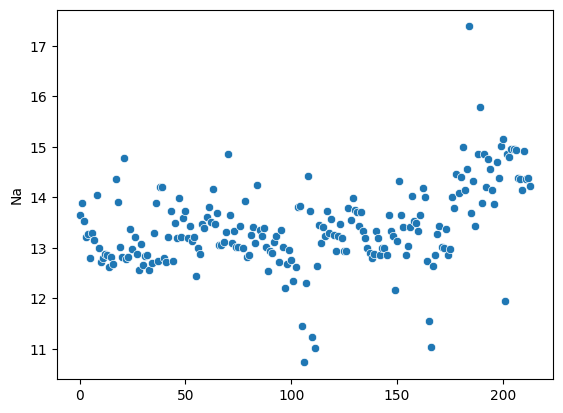

In [ ]:
#scatter plot
sns.scatterplot(df['Na'])

<Axes: ylabel='Mg'>

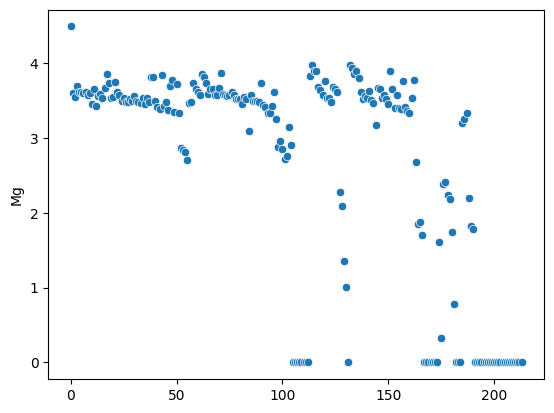

In [ ]:
#scatter plot
sns.scatterplot(df['Mg'])

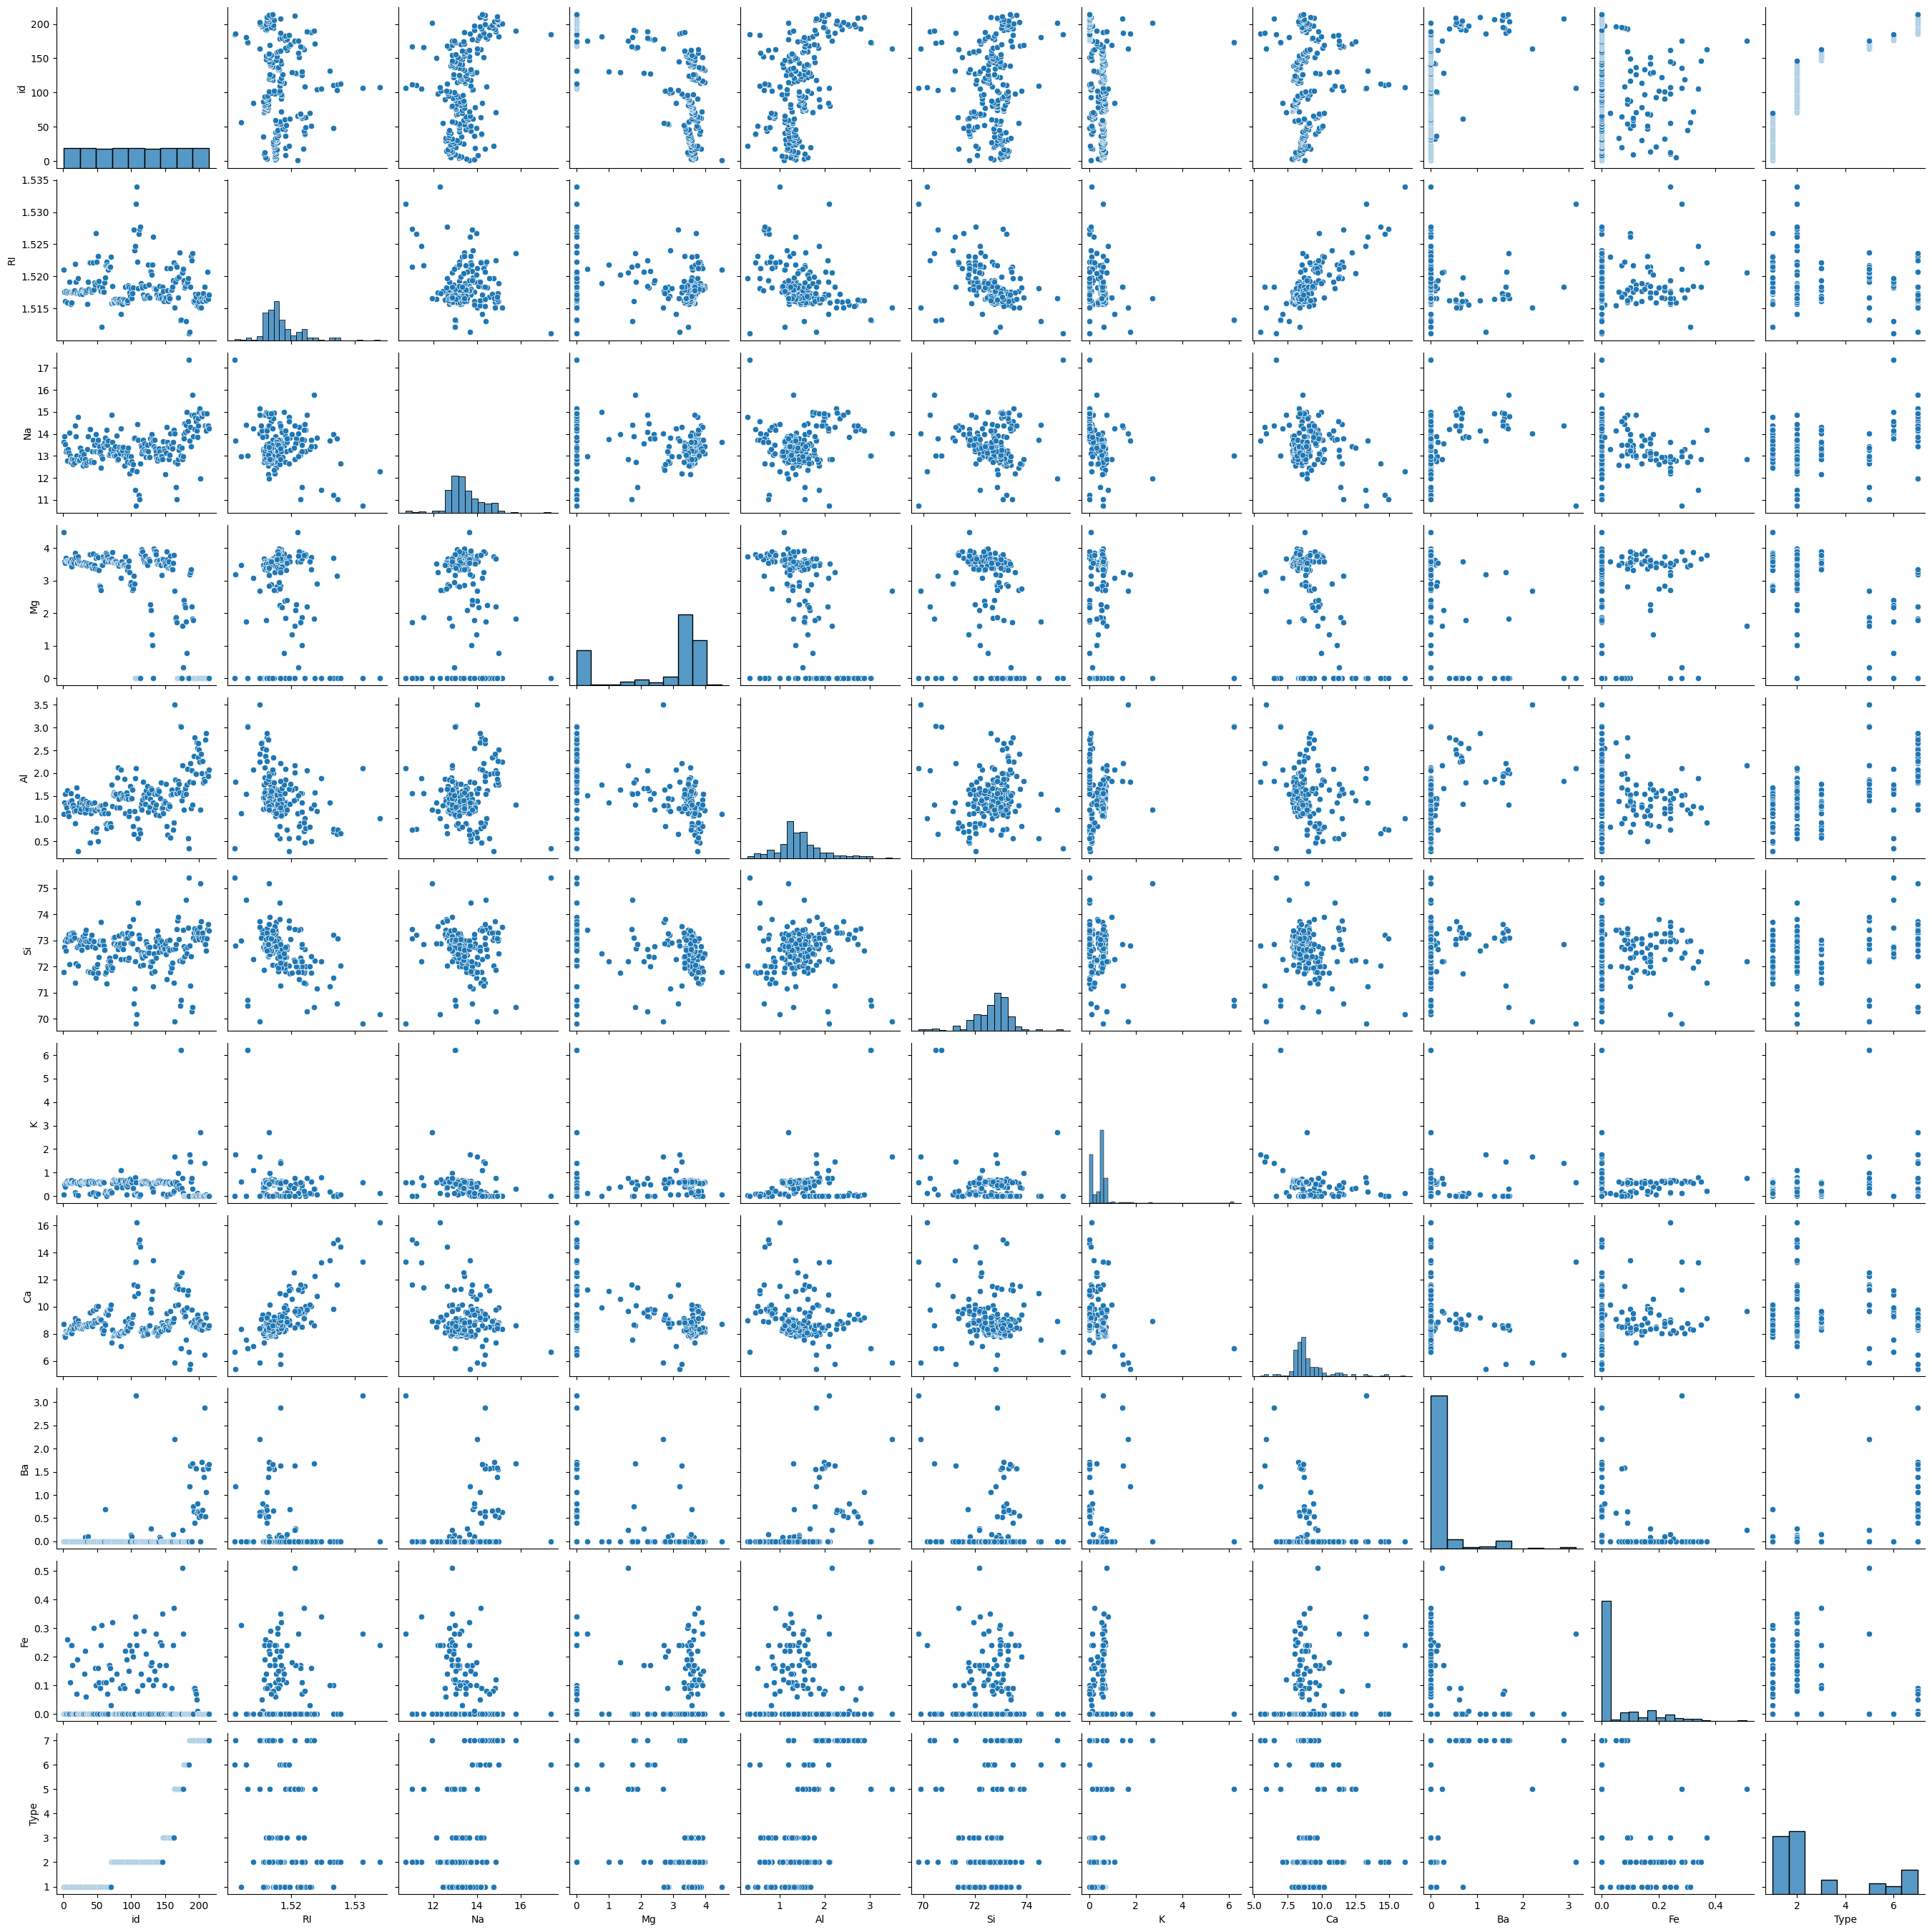

In [ ]:
sns.pairplot(df)

<Axes: ylabel='RI'>

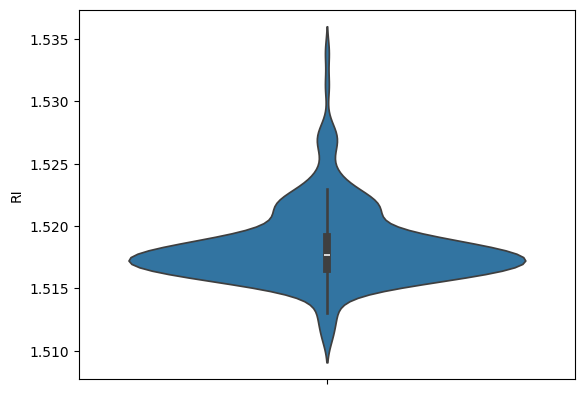

In [ ]:
#violin plot
sns.violinplot(df['RI'])

<Axes: ylabel='Na'>

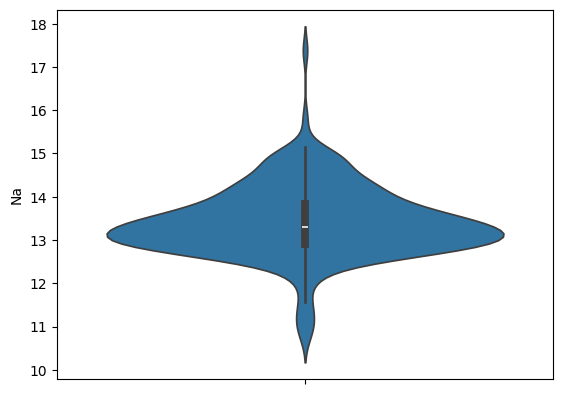

In [ ]:
sns.violinplot(df['Na'])

<Axes: ylabel='Mg'>

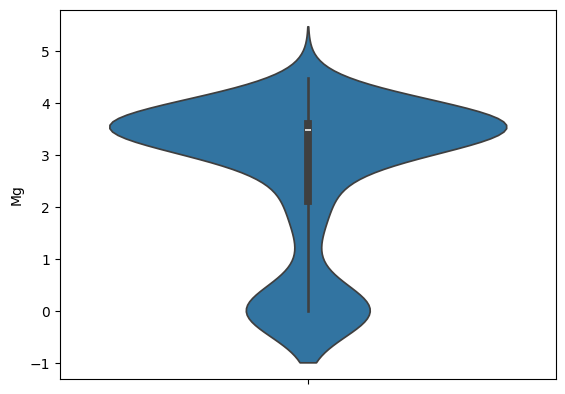

In [ ]:
sns.violinplot(df['Mg'])

<Axes: ylabel='Al'>

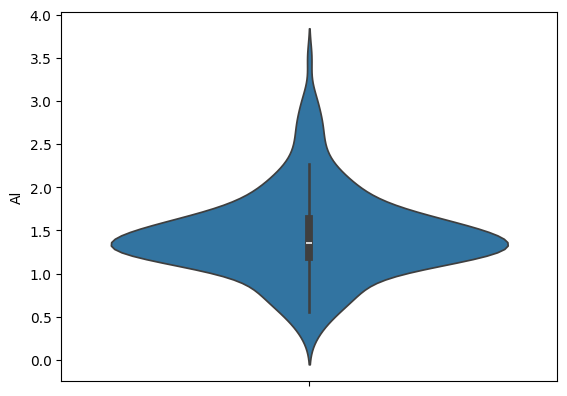

In [ ]:
sns.violinplot(df['Al'])

<Axes: ylabel='Si'>

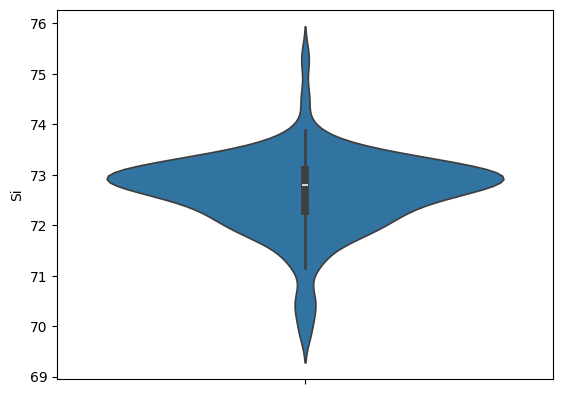

In [ ]:
sns.violinplot(df['Si'])

<Axes: ylabel='K'>

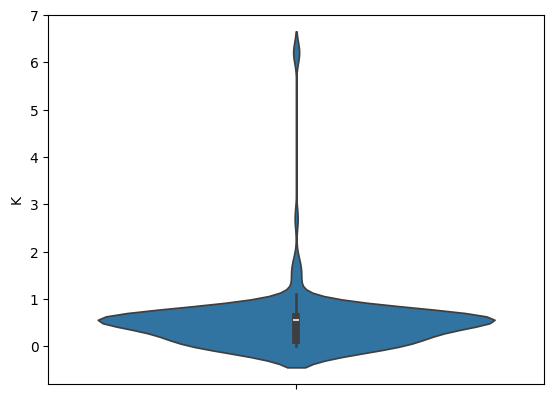

In [ ]:
sns.violinplot(df['K'])

<Axes: ylabel='K'>

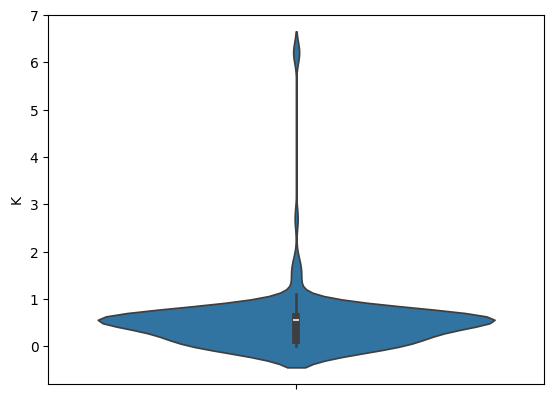

In [ ]:
sns.violinplot(df['K'])

<Axes: ylabel='Ca'>

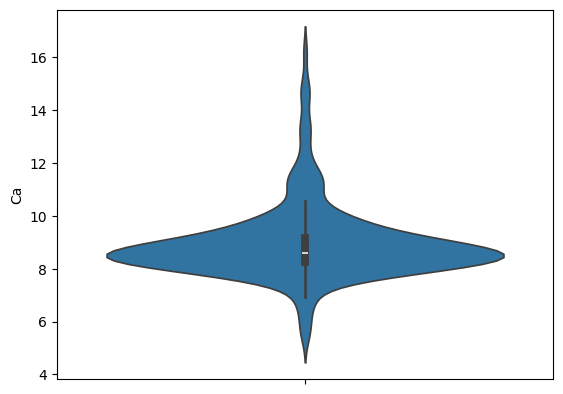

In [ ]:
sns.violinplot(df['Ca'])

<Axes: ylabel='Ba'>

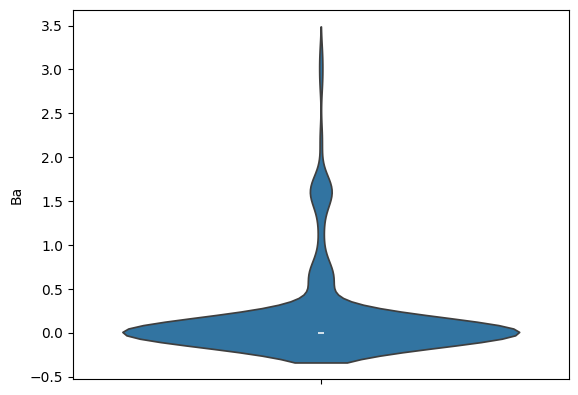

In [ ]:
sns.violinplot(df['Ba'])

<Axes: ylabel='Fe'>

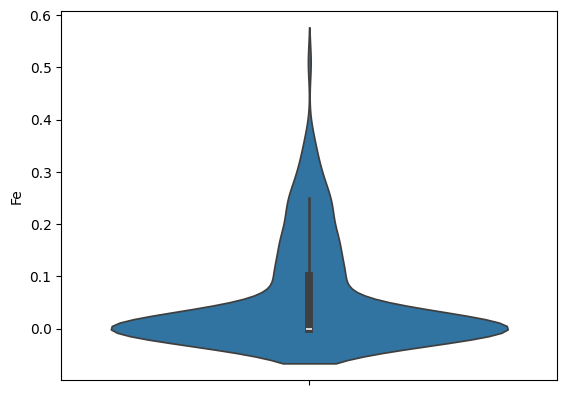

In [ ]:
sns.violinplot(df['Fe'])

<Axes: ylabel='RI'>

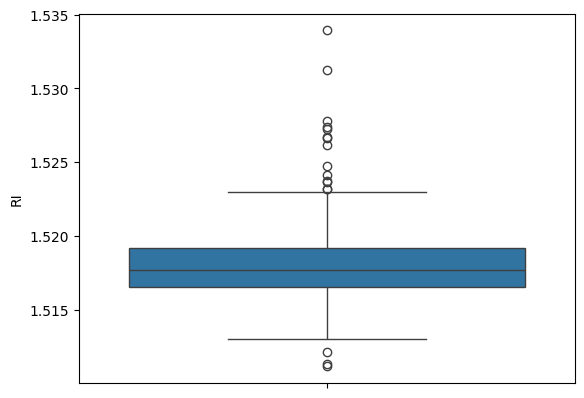

In [ ]:
#box plot
sns.boxplot(df['RI'])

<Axes: ylabel='Na'>

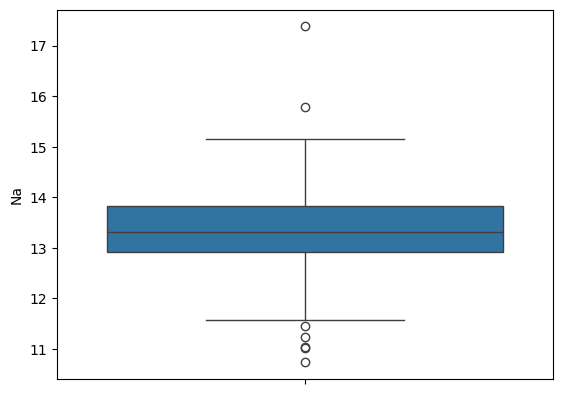

In [ ]:
#box plot
sns.boxplot(df['Na'])

<Axes: ylabel='Mg'>

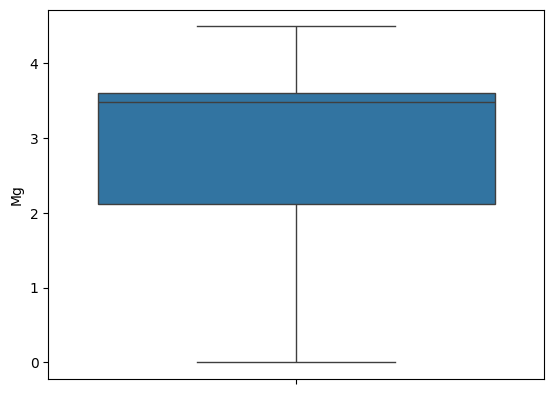

In [ ]:
#box plot
sns.boxplot(df['Mg'])

<Axes: ylabel='Al'>

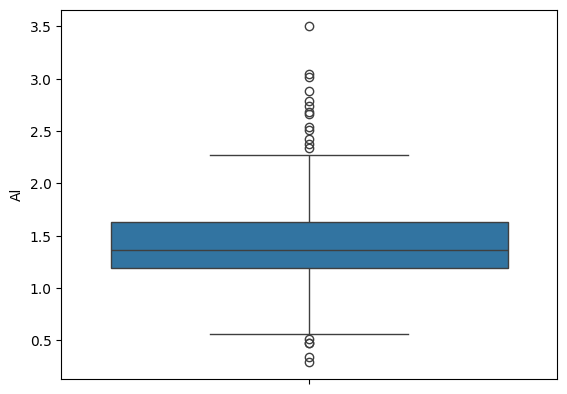

In [ ]:
#box plot
sns.boxplot(df['Al'])

<Axes: ylabel='Si'>

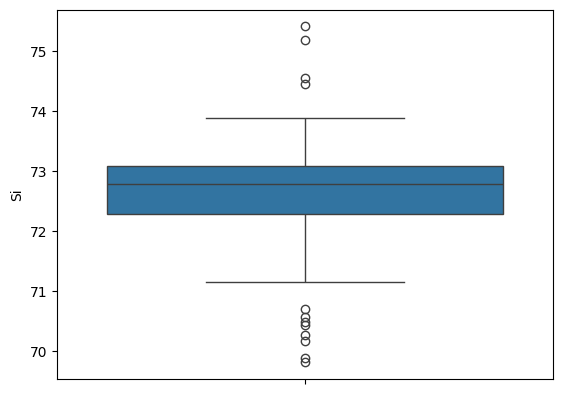

In [ ]:
#box plot
sns.boxplot(df['Si'])

<Axes: ylabel='K'>

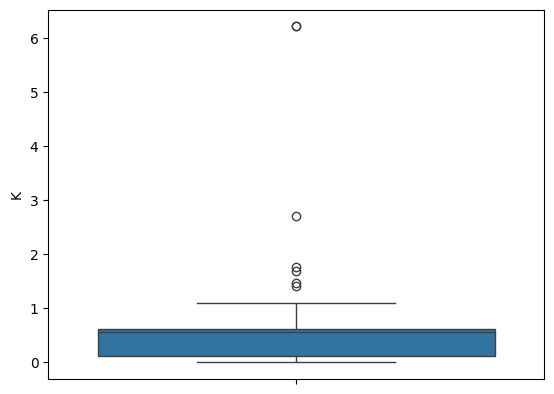

In [ ]:
#box plot
sns.boxplot(df['K'])

<Axes: ylabel='Ca'>

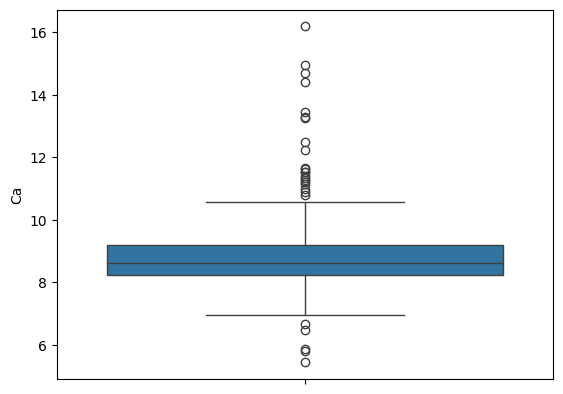

In [ ]:
#box plot
sns.boxplot(df['Ca'])

<Axes: ylabel='Ba'>

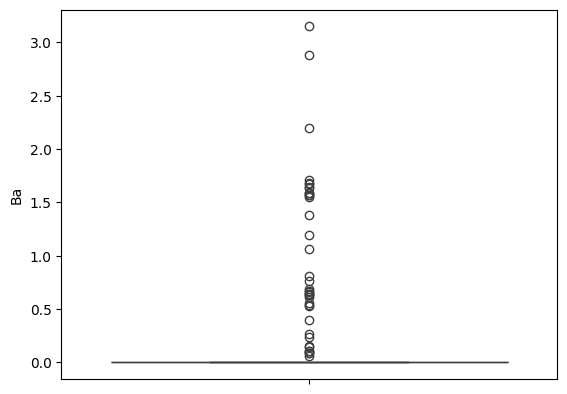

In [ ]:
#box plot
sns.boxplot(df['Ba'])

<Axes: ylabel='Fe'>

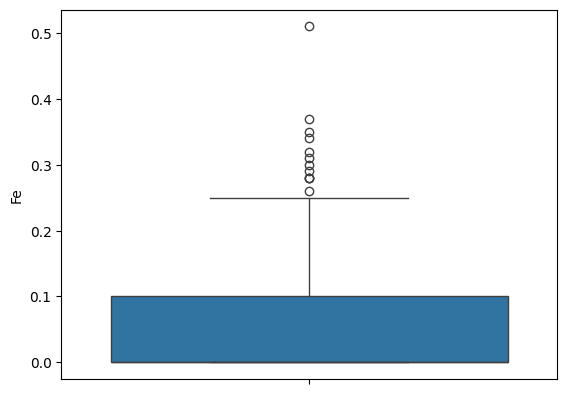

In [ ]:
#box plot
sns.boxplot(df['Fe'])

In [ ]:
#from domain knowledge get the idea of all the attributes, from plot it may seem that any element is not needed but from domain knowledge it is needed.

In [ ]:
#1 bina feature extracton train krna hai (without pca)

In [ ]:
#2 with feature extration train krna hai (with pc)


In [ ]:
df.drop(columns=['id'],inplace=True)

In [ ]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [ ]:
#splitting input and output as x and y
x = df.iloc[:, 0:-1]   # sab columns except first and last
y = df.iloc[:, -1]     # last column


In [ ]:
x

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


In [ ]:
y

,Type
0,1
1,1
2,1
3,1
4,1
...,...
209,7
210,7
211,7
212,7


In [ ]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
79,1.51590,12.82,3.52,1.90,72.86,0.69,7.97,0.00,0.00
161,1.51934,13.64,3.54,0.75,72.65,0.16,8.89,0.15,0.24
109,1.51818,13.72,0.00,0.56,74.45,0.00,10.99,0.00,0.00
127,1.52081,13.78,2.28,1.43,71.99,0.49,9.85,0.00,0.17
95,1.51860,13.36,3.43,1.43,72.26,0.51,8.60,0.00,0.00


In [ ]:
#knn
from sklearn.neighbors import KNeighborsClassifier
model4 = KNeighborsClassifier(n_neighbors=4,weights='distance',leaf_size=20)


In [ ]:
model4.fit(x_train, y_train)

KNeighborsClassifier(leaf_size=20, n_neighbors=4, weights='distance')

In [ ]:
knn_pred = model4.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
print("Accuracy: ", accuracy_score(y_test, knn_pred))
print("F1_score: ", f1_score(y_test, knn_pred, average='weighted'))   #for multi class set average  = weighted
print("Precision_score: ", precision_score(y_test, knn_pred, average='weighted'))
print("Recall_score:", recall_score(y_test, knn_pred, average='weighted'))
print(confusion_matrix(y_test, knn_pred))

Accuracy:  0.7906976744186046
F1_score:  0.7873815676141258
Precision_score:  0.7898032200357782
Recall_score: 0.7906976744186046
[[ 9  1  1  0  0  0]
 [ 3 11  0  0  0  0]
 [ 1  0  2  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  1  0  0  1  1]
 [ 0  0  0  0  1  7]]


In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
model5 = RandomForestClassifier(n_estimators=250,max_depth=10,criterion="gini",bootstrap=True, oob_score=True, n_jobs=-1, random_state=3, verbose=1)  #n_estimators yani ki no. of trees in a forest
#max_depth tree ka size
#oob_score is out of bag error
#n_jobs is used for core and thread ...
#assumption 1

In [ ]:
model5.fit(x_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:    1.4s finished


RandomForestClassifier(max_depth=10, n_estimators=250, n_jobs=-1,
                       oob_score=True, random_state=3, verbose=1)

In [ ]:
rfc_pred = model5.predict(x_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 250 out of 250 | elapsed:    0.1s finished


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
print("Accuracy: ", accuracy_score(y_test, rfc_pred))
print("F1_score: ", f1_score(y_test, rfc_pred, average='weighted'))   #for multi class set average  = weighted
print("Precision_score: ", precision_score(y_test, rfc_pred, average='weighted'))
print("Recall_score:", recall_score(y_test, rfc_pred, average='weighted'))
print(confusion_matrix(y_test, rfc_pred))

Accuracy:  0.8604651162790697
F1_score:  0.8573412907202236
Precision_score:  0.881512802443035
Recall_score: 0.8604651162790697
[[11  0  0  0  0  0]
 [ 3 10  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


In [ ]:
#ensemblee learning =
# 2 types homo and hetro
#homo is same family
# hetro is different family


In [ ]:
#decision tree
#Decision tree classifier
# dtc when classifier and dtr when regression
# decison tree overift krta h sbse jyada
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [ ]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
dtc_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score ,precision_score, recall_score, confusion_matrix
print("Accuracy: ", accuracy_score(y_test, dtc_pred))


Accuracy:  0.8372093023255814


In [ ]:
print("F1_score: ", f1_score(y_test, dtc_pred, average='weighted'))   #for multi class set average  = weighted

F1_score:  0.8312603948718861


In [ ]:
print("Precision_score: ", precision_score(y_test, dtc_pred, average='weighted'))

Precision_score:  0.8766149870801033


In [ ]:
print("Recall_score: ", recall_score(y_test, dtc_pred, average='weighted'))

Recall_score:  0.8372093023255814


In [ ]:
## ensemble (random forest , extra tree classisifier , xg boost )
#kiski accuracy jyada h

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model1 = RandomForestClassifier()

In [ ]:
model1.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
dtc_pred1 = model1.predict(x_test)

In [ ]:
print("F1_score: ", f1_score(y_test, dtc_pred1, average='weighted'))   #for multi class set average  = weighted

F1_score:  0.8077468713583624


In [ ]:
from sklearn.tree import ExtraTreeClassifier
model2 = ExtraTreeClassifier()

In [ ]:
model2.fit(x_train,y_train)

ExtraTreeClassifier()

In [ ]:
dtc_pred2 = model2.predict(x_test)

In [ ]:
print("F1_score: ", f1_score(y_test, dtc_pred2, average='weighted'))   #for multi class set average  = weighted

F1_score:  0.7465456466824455


In [ ]:
#XGboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target labels to 0 to n_classes-1
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model3 = XGBClassifier()

In [ ]:
model3.fit(x_train,y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = model3.predict(x_test)
print("F1_score: ", f1_score(y_test_encoded, xgb_pred, average='weighted'))

F1_score:  0.8321010102726633


In [ ]:
#optimization using grid search cv  , cross validation...
from sklearn.model_selection import GridSearchCV


In [ ]:
# stagging
# weak or base learner = m1 , m2 , m3 ..................mn.
# meta learner = m1 (one with highest accuracy)
